
# Traffic Growth vs Commercial Efficiency

Notebook này tạo 3 hình cho phần EDA 2:

1. **Top funnel**: sessions, unique visitors, signups theo tháng  
2. **Conversion proxy vs bounce rate**: conversion proxy = non-cancelled orders / sessions  
3. **Commercial efficiency per 1,000 sessions**: orders, revenue và gross profit trên mỗi 1,000 sessions  



## 1. Import thư viện và cấu hình đường dẫn

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Nếu notebook nằm cùng thư mục với các file CSV thì giữ DATA_DIR = Path(".")
# Nếu chạy trong môi trường ChatGPT hiện tại, notebook sẽ tự fallback sang /mnt/data.
DATA_DIR = Path("C:/Users/Admin/Downloads/Vin Datathon/data")
OUT_DIR = Path("C:/Users/Admin/Downloads/Vin Datathon/EDA")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR.resolve())
print("OUT_DIR:", OUT_DIR.resolve())

TITLE_SIZE = 25
LABEL_SIZE = 20
TICK_SIZE = 11
LEGEND_SIZE = 17
ANNOT_SIZE = 10


DATA_DIR: C:\Users\Admin\Downloads\Vin Datathon\data
OUT_DIR: C:\Users\Admin\Downloads\Vin Datathon\EDA


## 2. Load dữ liệu

In [2]:

required_files = [
    "web_traffic.csv",
    "orders.csv",
    "customers.csv",
    "sales.csv",
]

missing = [f for f in required_files if not (DATA_DIR / f).exists()]
if missing:
    raise FileNotFoundError(f"Missing required files: {missing}")

traffic = pd.read_csv(DATA_DIR / "web_traffic.csv", parse_dates=["date"])
orders = pd.read_csv(DATA_DIR / "orders.csv", parse_dates=["order_date"])
customers = pd.read_csv(DATA_DIR / "customers.csv", parse_dates=["signup_date"])
sales = pd.read_csv(DATA_DIR / "sales.csv", parse_dates=["Date"])

print("traffic:", traffic.shape)
print("orders:", orders.shape)
print("customers:", customers.shape)
print("sales:", sales.shape)


traffic: (3652, 7)
orders: (646945, 8)
customers: (121930, 7)
sales: (3833, 3)


## 3. Tạo monthly funnel panel

In [3]:

def weighted_average(values: pd.Series, weights: pd.Series) -> float:
    """Return weighted average; fallback to simple mean if weights are invalid."""
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")
    mask = values.notna() & weights.notna() & (weights > 0)
    if not mask.any():
        return values.mean()
    return np.average(values[mask], weights=weights[mask])


def build_monthly_funnel_panel(
    traffic: pd.DataFrame,
    orders: pd.DataFrame,
    customers: pd.DataFrame,
    sales: pd.DataFrame,
) -> pd.DataFrame:
    """Build monthly top-funnel and commercial efficiency panel."""
    traffic = traffic.copy()
    orders = orders.copy()
    customers = customers.copy()
    sales = sales.copy()

    traffic["month"] = traffic["date"].dt.to_period("M").dt.to_timestamp()
    orders["month"] = orders["order_date"].dt.to_period("M").dt.to_timestamp()
    customers["month"] = customers["signup_date"].dt.to_period("M").dt.to_timestamp()
    sales["month"] = sales["Date"].dt.to_period("M").dt.to_timestamp()

    traffic_m = (
        traffic.groupby("month")
        .apply(
            lambda g: pd.Series({
                "sessions": g["sessions"].sum(),
                "unique_visitors": g["unique_visitors"].sum(),
                "page_views": g["page_views"].sum(),
                "bounce_rate": weighted_average(g["bounce_rate"], g["sessions"]),
                "avg_session_duration_sec": weighted_average(g["avg_session_duration_sec"], g["sessions"]),
            })
        )
        .reset_index()
    )

    orders_m = (
        orders.groupby("month", as_index=False)
        .agg(
            total_orders=("order_id", "nunique"),
            non_cancelled_orders=("order_status", lambda s: s.ne("cancelled").sum()),
            unique_buyers=("customer_id", "nunique"),
        )
    )

    signups_m = (
        customers.groupby("month", as_index=False)
        .agg(signups=("customer_id", "nunique"))
    )

    sales_m = (
        sales.groupby("month", as_index=False)
        .agg(
            revenue=("Revenue", "sum"),
            cogs=("COGS", "sum"),
        )
    )
    sales_m["gross_profit"] = sales_m["revenue"] - sales_m["cogs"]

    monthly = (
        traffic_m
        .merge(orders_m, on="month", how="left")
        .merge(signups_m, on="month", how="left")
        .merge(sales_m, on="month", how="left")
        .sort_values("month")
    )

    fill_cols = [
        "total_orders",
        "non_cancelled_orders",
        "unique_buyers",
        "signups",
        "revenue",
        "cogs",
        "gross_profit",
    ]
    monthly[fill_cols] = monthly[fill_cols].fillna(0)

    monthly["conversion_proxy"] = (
        monthly["non_cancelled_orders"] / monthly["sessions"].replace(0, np.nan)
    )
    monthly["orders_per_1000_sessions"] = monthly["conversion_proxy"] * 1000
    monthly["revenue_per_1000_sessions"] = (
        monthly["revenue"] / monthly["sessions"].replace(0, np.nan) * 1000
    )
    monthly["gross_profit_per_1000_sessions"] = (
        monthly["gross_profit"] / monthly["sessions"].replace(0, np.nan) * 1000
    )

    return monthly


monthly = build_monthly_funnel_panel(traffic, orders, customers, sales)

monthly.head()

def apply_readable_style(
    ax,
    *,
    title_size=TITLE_SIZE,
    label_size=LABEL_SIZE,
    tick_size=TICK_SIZE,
    legend_size=LEGEND_SIZE,
):
    """Increase title/label/tick/legend font size without changing figure size."""
    ax.title.set_fontsize(title_size)
    ax.xaxis.label.set_fontsize(label_size)
    ax.yaxis.label.set_fontsize(label_size)
    ax.tick_params(axis="both", labelsize=tick_size)

    legend = ax.get_legend()
    if legend is not None:
        for text in legend.get_texts():
            text.set_fontsize(legend_size)


## 4. Hình 1 — Top Funnel: Sessions, Unique Visitors, Signups

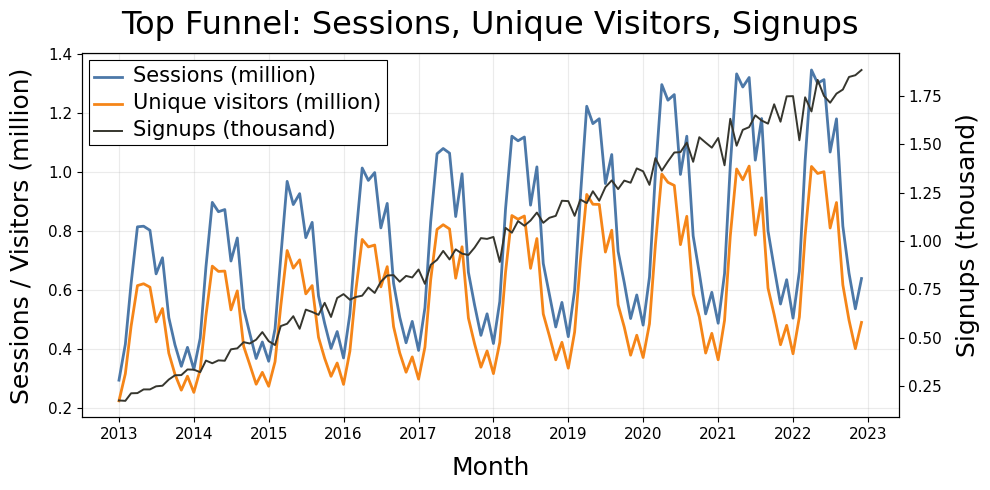

Saved: C:\Users\Admin\Downloads\Vin Datathon\EDA\eda2_top_funnel_sessions_visitors_signups.png


In [4]:

def plot_top_funnel(monthly: pd.DataFrame, *, output_base: Path) -> None:
    """Plot sessions, unique visitors and signups over time."""
    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.plot(
        monthly["month"],
        monthly["sessions"] / 1e6,
        label="Sessions (million)",
        linewidth=2,
        color =  "#4C78A8"
    )
    ax1.plot(
        monthly["month"],
        monthly["unique_visitors"] / 1e6,
        label="Unique visitors (million)",
        linewidth=2,
        color = "#F58518"
    )

    ax1.set_title("Top Funnel: Sessions, Unique Visitors, Signups", pad=14)
    ax1.set_xlabel("Month",labelpad=10)
    ax1.set_ylabel("Sessions / Visitors (million)", labelpad=10)
    ax1.grid(True, alpha=0.25)

    ax2 = ax1.twinx()
    ax2.plot(
        monthly["month"],
        monthly["signups"] / 1e3,
        label="Signups (thousand)",
        linewidth=1.4,
        color="#36362EFF",
    )
    ax2.set_ylabel("Signups (thousand)", labelpad=10)

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()

    legend = ax1.legend(
        lines_1 + lines_2,
        labels_1 + labels_2,
        loc="upper left",
        frameon=True,
        fancybox=False,
        edgecolor="black",
    )
    legend.get_frame().set_linewidth(0.8)
    legend.get_frame().set_alpha(1.0)
    legend.get_frame().set_facecolor("white")
    apply_readable_style(ax1)
    apply_readable_style(ax2)
    fig.tight_layout()

    output_png = output_base.with_suffix(".png")
    fig.savefig(output_png, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", output_png)


plot_top_funnel(
    monthly,
    output_base=OUT_DIR / "eda2_top_funnel_sessions_visitors_signups",
)


## 5. Hình 2 — Conversion Proxy vs Bounce Rate

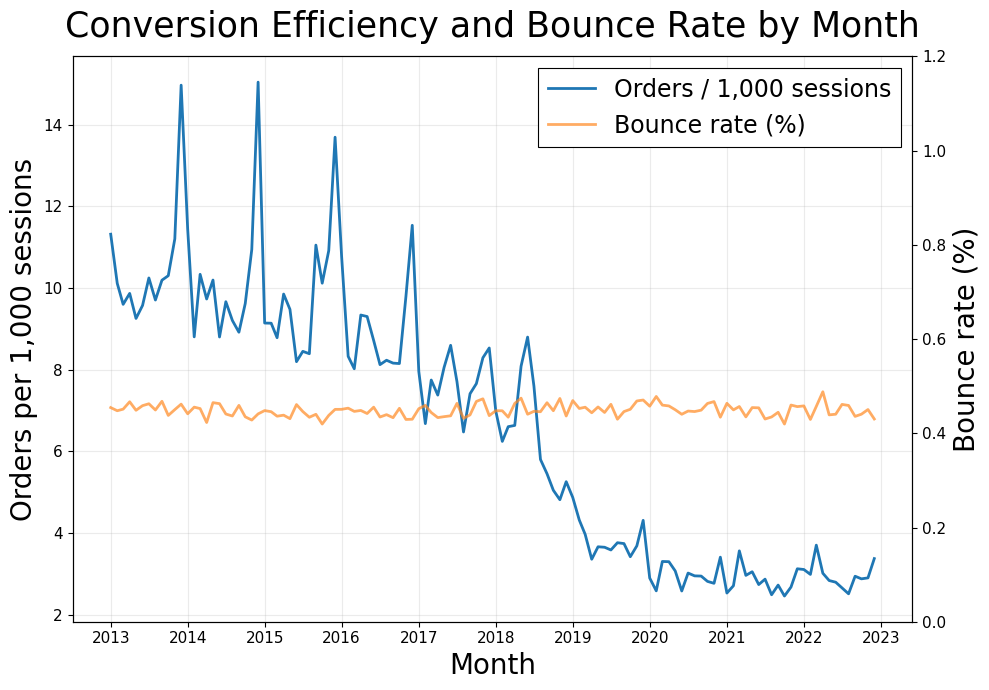

Saved: C:\Users\Admin\Downloads\Vin Datathon\EDA\eda2_conversion_proxy_bounce_rate.png


In [14]:
def plot_conversion_bounce(monthly: pd.DataFrame, *, output_base: Path) -> None:
    fig, ax1 = plt.subplots(figsize=(10, 7))

    # Left axis: orders per 1,000 sessions
    ax1.plot(
        monthly["month"],
        monthly["orders_per_1000_sessions"],
        label="Orders / 1,000 sessions",
        linewidth=2,
        color="#1f77b4",
    )

    ax1.set_title(
        "Conversion Efficiency and Bounce Rate by Month",
        pad=14,
        fontsize=TITLE_SIZE,
    )
    ax1.set_xlabel("Month", fontsize=LABEL_SIZE)
    ax1.set_ylabel("Orders per 1,000 sessions", fontsize=LABEL_SIZE)
    ax1.tick_params(axis="both", labelsize=TICK_SIZE)
    ax1.grid(True, alpha=0.25)

    # Right axis: bounce rate
    ax2 = ax1.twinx()
    ax2.plot(
        monthly["month"],
        monthly["bounce_rate"]*100,
        label="Bounce rate (%)",
        linewidth=2,
        color="#ff8a24b5",
    )

    ax2.set_ylabel("Bounce rate (%)", fontsize=LABEL_SIZE)
    ax2.tick_params(axis="both", labelsize=TICK_SIZE)

    # Mở rộng trục y để bounce rate nhìn ít dao động hơn
    ax2.set_ylim(0, 1.2)

    # Combined legend
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()

    legend = ax1.legend(
        lines_1 + lines_2,
        labels_1 + labels_2,
        loc="upper right",
        frameon=True,
        fancybox=False,
        edgecolor="black",
        fontsize=LEGEND_SIZE,
    )
    legend.get_frame().set_linewidth(0.8)
    legend.get_frame().set_alpha(1.0)
    legend.get_frame().set_facecolor("white")

    fig.tight_layout()

    output_png = output_base.with_suffix(".png")
    fig.savefig(output_png, dpi=330, bbox_inches="tight")
    plt.show()

    print("Saved:", output_png)

plot_conversion_bounce(
    monthly,
    output_base=OUT_DIR / "eda2_conversion_proxy_bounce_rate",
)

## 6. Hình 3 — Commercial Efficiency per 1,000 Sessions

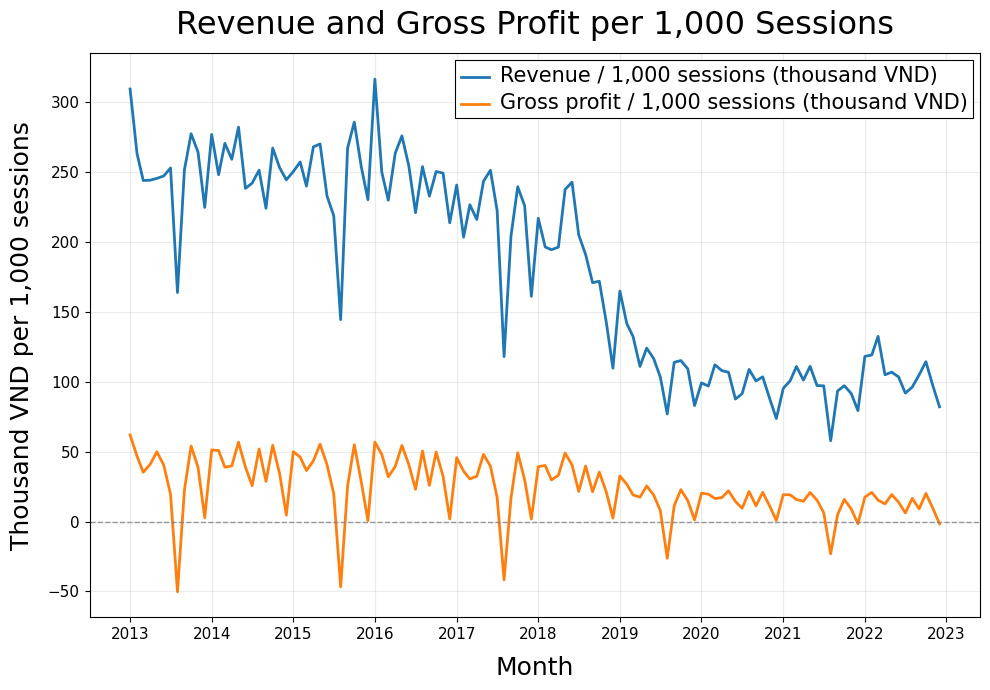

Saved: C:\Users\Admin\Downloads\Vin Datathon\EDA\eda2_revenue_gp_per_1000_sessions.png


,metric,first24_median,last24_median,absolute_change,pct_change
0,Sessions,"580,165.50","918,869.50","338,704.00",58.4%
1,"Orders / 1,000 sessions",9.99,2.87,-7.12,-71.2%
2,"Revenue / 1,000 sessions","251,511.18","99,034.99","-152,476.19",-60.6%
3,"Gross profit / 1,000 sessions","39,375.50","14,893.03","-24,482.47",-62.2%


In [15]:

def build_first_last_24_summary(monthly: pd.DataFrame) -> pd.DataFrame:
    """Build first-24-month vs last-24-month median comparison."""
    monthly = monthly.sort_values("month").copy()

    first24 = monthly.head(24)
    last24 = monthly.tail(24)

    metrics = [
        ("Sessions", "sessions"),
        ("Orders / 1,000 sessions", "orders_per_1000_sessions"),
        ("Revenue / 1,000 sessions", "revenue_per_1000_sessions"),
        ("Gross profit / 1,000 sessions", "gross_profit_per_1000_sessions"),
    ]

    rows = []
    for label, col in metrics:
        first_val = first24[col].median()
        last_val = last24[col].median()
        rows.append({
            "metric": label,
            "first24_median": first_val,
            "last24_median": last_val,
            "absolute_change": last_val - first_val,
            "pct_change": last_val / first_val - 1 if first_val != 0 else np.nan,
        })

    return pd.DataFrame(rows)


def plot_commercial_efficiency(monthly: pd.DataFrame, *, output_base: Path) -> None:
    """Plot revenue and gross profit per 1,000 sessions over time."""
    fig, ax = plt.subplots(figsize=(10, 7))

    ax.plot(
        monthly["month"],
        monthly["revenue_per_1000_sessions"] / 1e3,
        label="Revenue / 1,000 sessions (thousand VND)",
        linewidth=2,
    )

    ax.plot(
        monthly["month"],
        monthly["gross_profit_per_1000_sessions"] / 1e3,
        label="Gross profit / 1,000 sessions (thousand VND)",
        linewidth=2,
    )

    ax.axhline(
    0,
    linestyle="--",
    linewidth=1.0,
    color="gray",
    alpha=0.8,
    )

    ax.set_title("Revenue and Gross Profit per 1,000 Sessions", pad=14)
    ax.set_xlabel("Month", labelpad=10)
    ax.set_ylabel("Thousand VND per 1,000 sessions", labelpad=10)
    ax.grid(True, alpha=0.25)

    legend = ax.legend(
        loc="upper right",
        frameon=True,
        fancybox=False,
        edgecolor="black",
    )
    legend.get_frame().set_linewidth(0.8)
    legend.get_frame().set_alpha(1.0)
    legend.get_frame().set_facecolor("white")
    apply_readable_style(ax)
    fig.tight_layout()

    output_png = output_base.with_suffix(".png")
    fig.savefig(output_png, dpi=330, bbox_inches="tight")
    plt.show()

    print("Saved:", output_png)


eff_summary = build_first_last_24_summary(monthly)

plot_commercial_efficiency(
    monthly,
    output_base=OUT_DIR / "eda2_revenue_gp_per_1000_sessions",
)

eff_summary.style.format({
    "first24_median": "{:,.2f}",
    "last24_median": "{:,.2f}",
    "absolute_change": "{:,.2f}",
    "pct_change": "{:.1%}",
})
